In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from cv_utils import *
from pitch_segmentation import *

import albumentations
from torchvision import *

import segmentation_models_pytorch as smp

In [2]:
train = False
generate = False
merge = False
convert = False
res_unet_train = False

In [3]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
coco_dataset_path_1 = os.path.join(data_path, 'coco_datasets/real_train_pitch_object')
coco_dataset_path_2 = os.path.join(data_path, 'coco_datasets/synth_train_pitch_object')
folder_name_1 = 'real_train_pitch_object'
folder_name_2 = 'synth_train_pitch_object'
if convert:
    cvat2coco(folder_name_1, data_path)
    cvat2coco(folder_name_2 , data_path)
if merge:
    dest_path=os.path.join(data_path, 'coco_datasets')
    pitch_object_dataset_path = merge_coco_dataset(coco_dataset_path_1, coco_dataset_path_2,
                    dest_path=os.path.join(data_path, 'coco_datasets'))
else:
    pitch_object_dataset_path = os.path.join(data_path, 'coco_datasets/real_synth_train_pitch_object')

pitch_segmenta_dataset_path = os.path.join(data_path, 'coco_datasets/real_synth_train_pitch')

if generate:
    complete_dataset_path = generate_complete_pitch_segment_dataset(data_path, pitch_object_dataset_path, pitch_segmenta_dataset_path)
else:
    complete_dataset_path = os.path.join(data_path, 'coco_datasets/completed_pitch_segments')

### Load data

<Figure size 2400x1800 with 0 Axes>

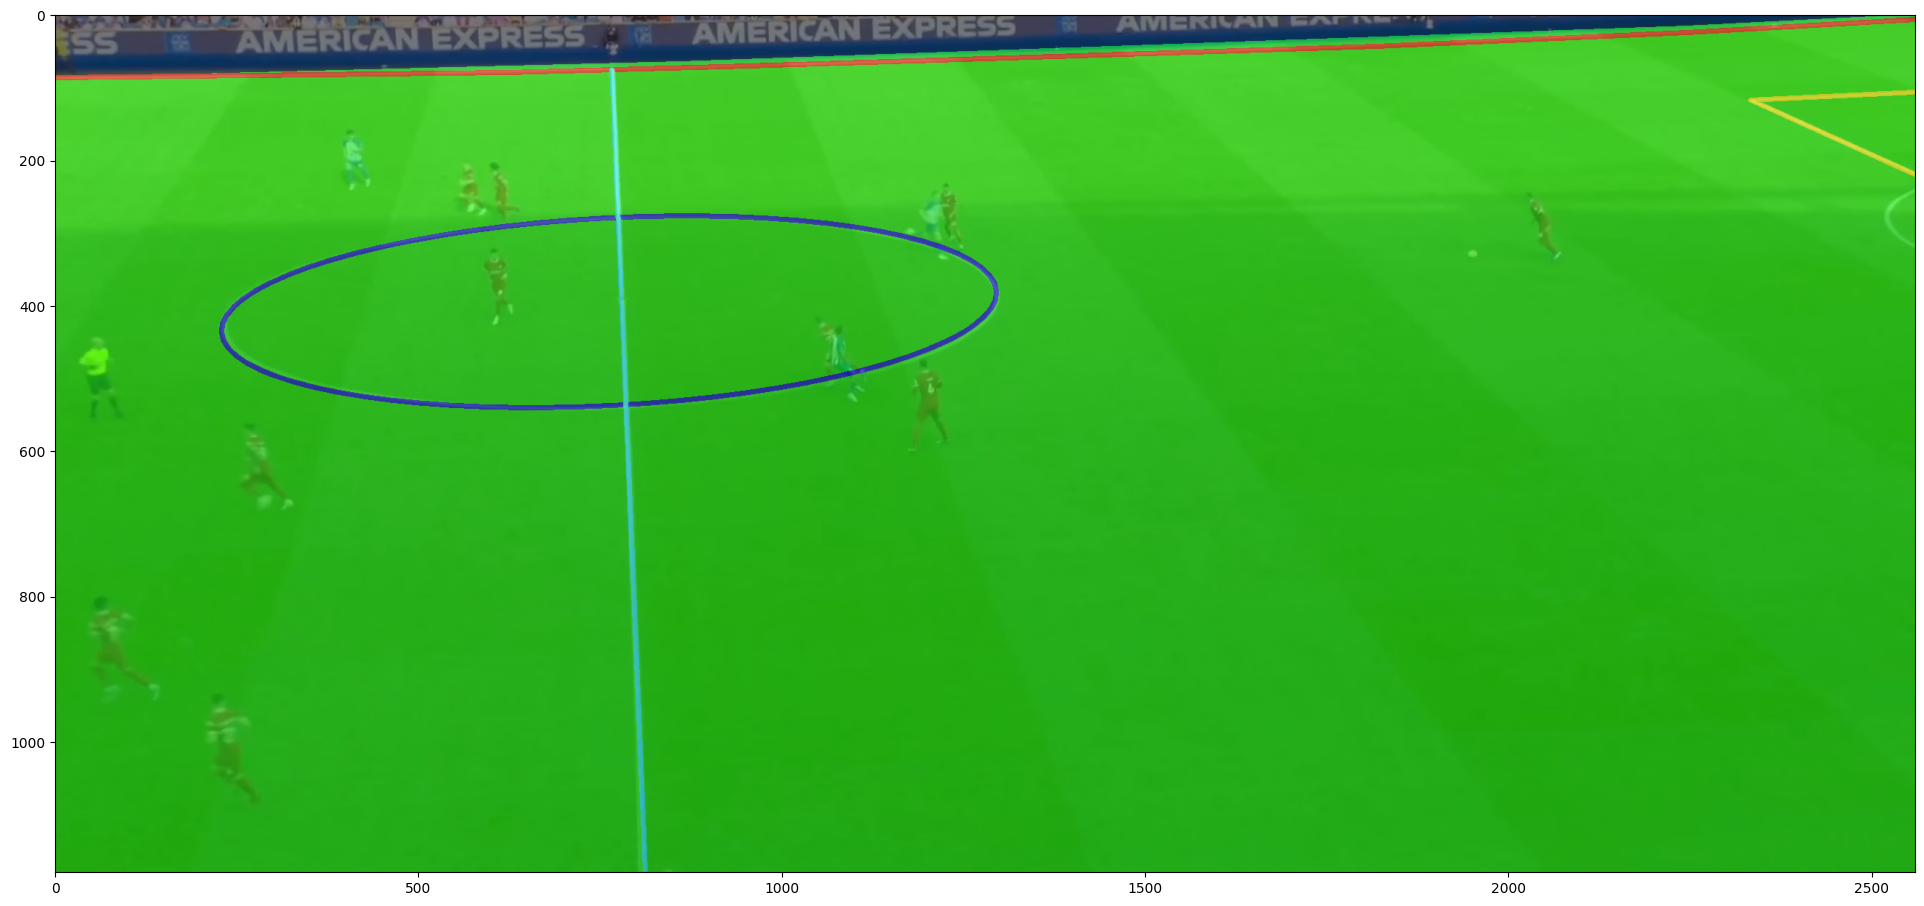

In [4]:
image_folder = os.path.join(complete_dataset_path, "images")
annotation_file = os.path.join(complete_dataset_path, "annotations", "instances_default.json")

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

for image_id in range(1, 2):
    image_name = [image_info["file_name"] for image_info in annotations['images']
                                            if image_info['id'] == image_id][0]
    annotation_list = [annotation 
                        for annotation in annotations['annotations']
                        if annotation['image_id'] == image_id]

    image_path = os.path.join(image_folder, image_name)
    image = cv2.cvtColor(cv2.imread(image_path, 
                                            cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB)
    plt.figure()


    mask = np.zeros(image.shape, dtype=np.uint8)
    #print(annotation_list)
    for annotation in annotation_list:
        if annotation['category_id'] == 1:
            contours = np.array(annotation['segmentation']).reshape(1, -1, 2).astype(np.int32)
            x, y, w, h = cv2.boundingRect(contours)
            cv2.drawContours(mask, contours, -1, (0, 255, 0), -1)
        elif annotation['category_id'] == 4:
            cv2.ellipse(mask, annotation['center'], annotation['length'],
                        annotation['angle'], 0, 360, (0, 0, 255), 5)
        elif annotation['category_id'] == 5:
            contours = np.array(annotation['segmentation']).reshape(1, -1, 2).astype(np.int32)
            cv2.drawContours(mask, contours, -1, (255, 255, 255), -1)
        else:
            line = np.array(annotation['segmentation']).reshape(1, -1, 2).astype(np.int32)[0]

            if annotation['category_id'] == 2:
                color = (255, 0, 0)
            elif annotation['category_id'] == 3:
                color = (255, 255, 0)
            elif annotation['category_id'] == 6:
                color = (0, 255, 255)
            #if len(line) == 2:
                #cv2.line(mask, line[0], line[1], color, 5)
            #else:
            cv2.polylines(mask, [line], False, color, 5)

    cropped_image = image[y:y + h, x:x + w]
    cropped_mask = mask[y:y + h, x:x + w]
    plt.figure()
    plt.imshow(cropped_image)
    plt.imshow(cropped_mask, alpha=0.5)

# mask = np.zeros(image.shape[:2], dtype=np.uint8)
# cv2.fillPoly(mask, [annotation], color=255)
# plt.figure()
# plt.imshow(mask, cmap='gray', vmin=0, vmax=255)

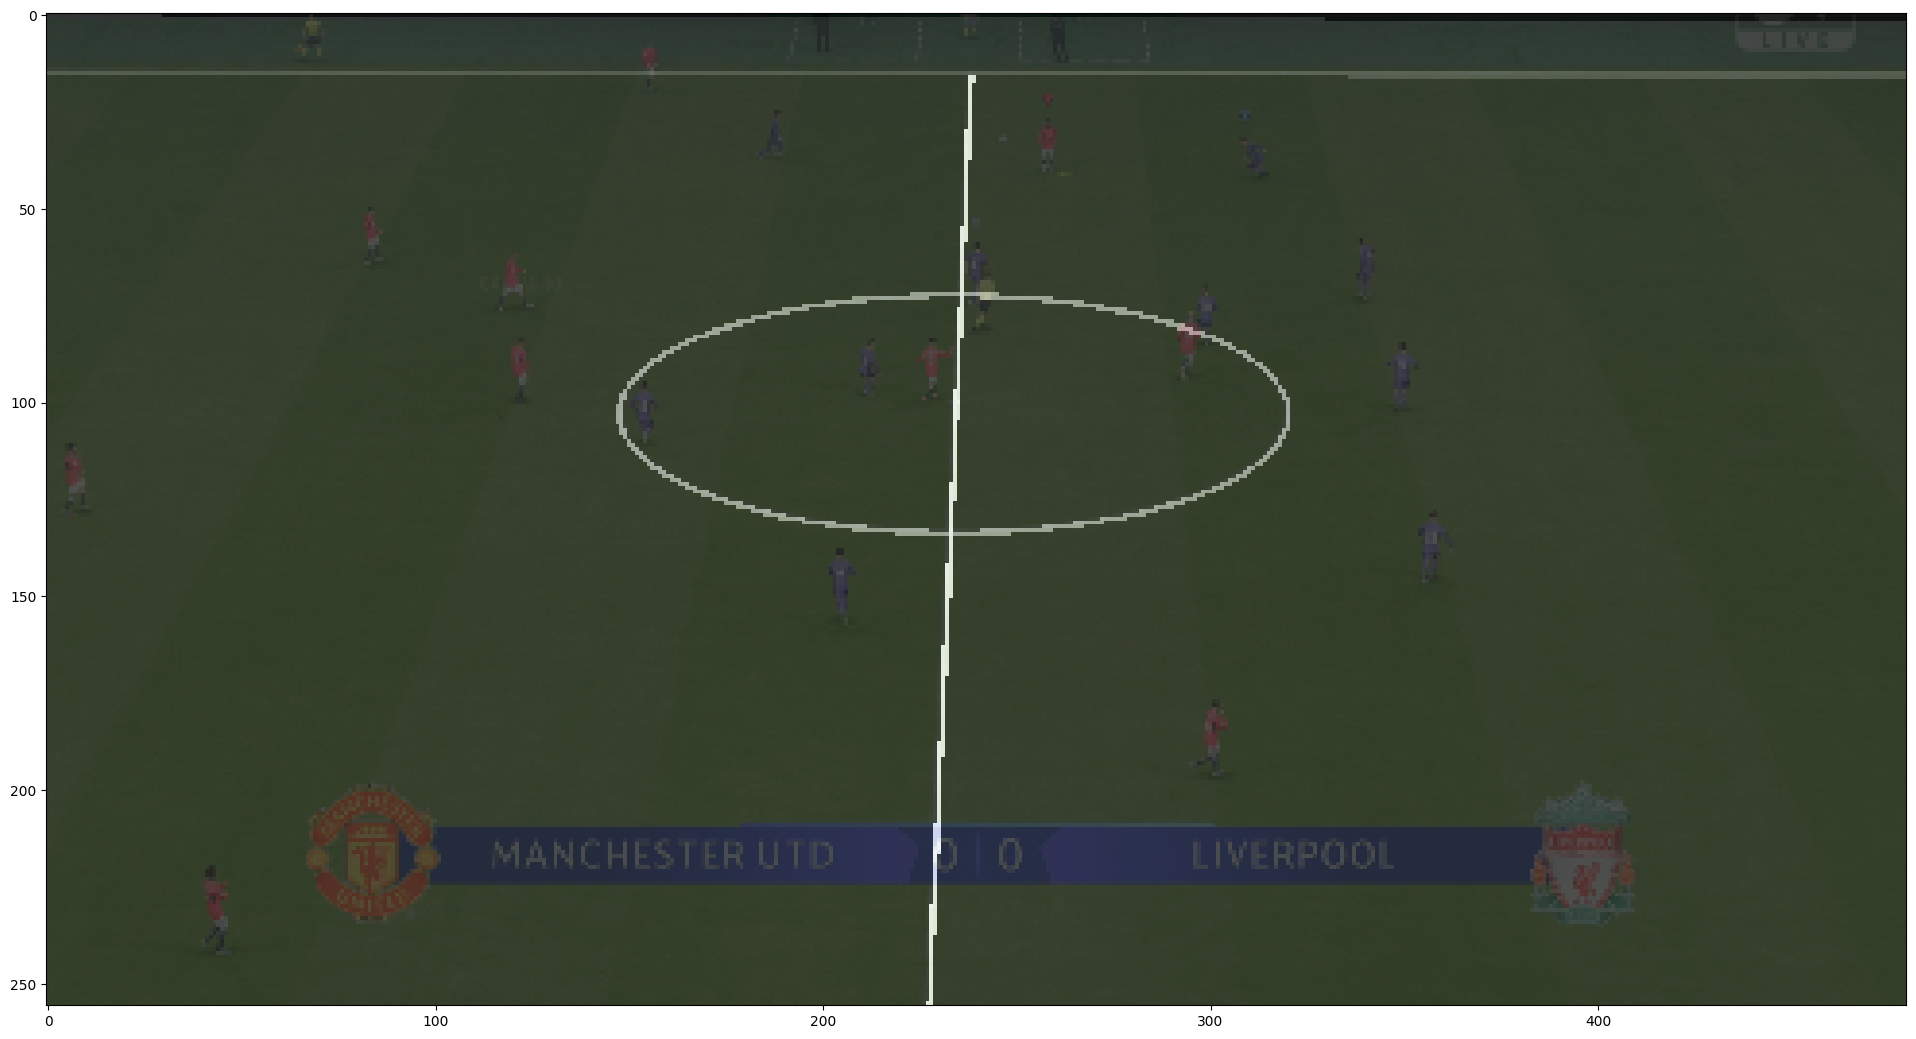

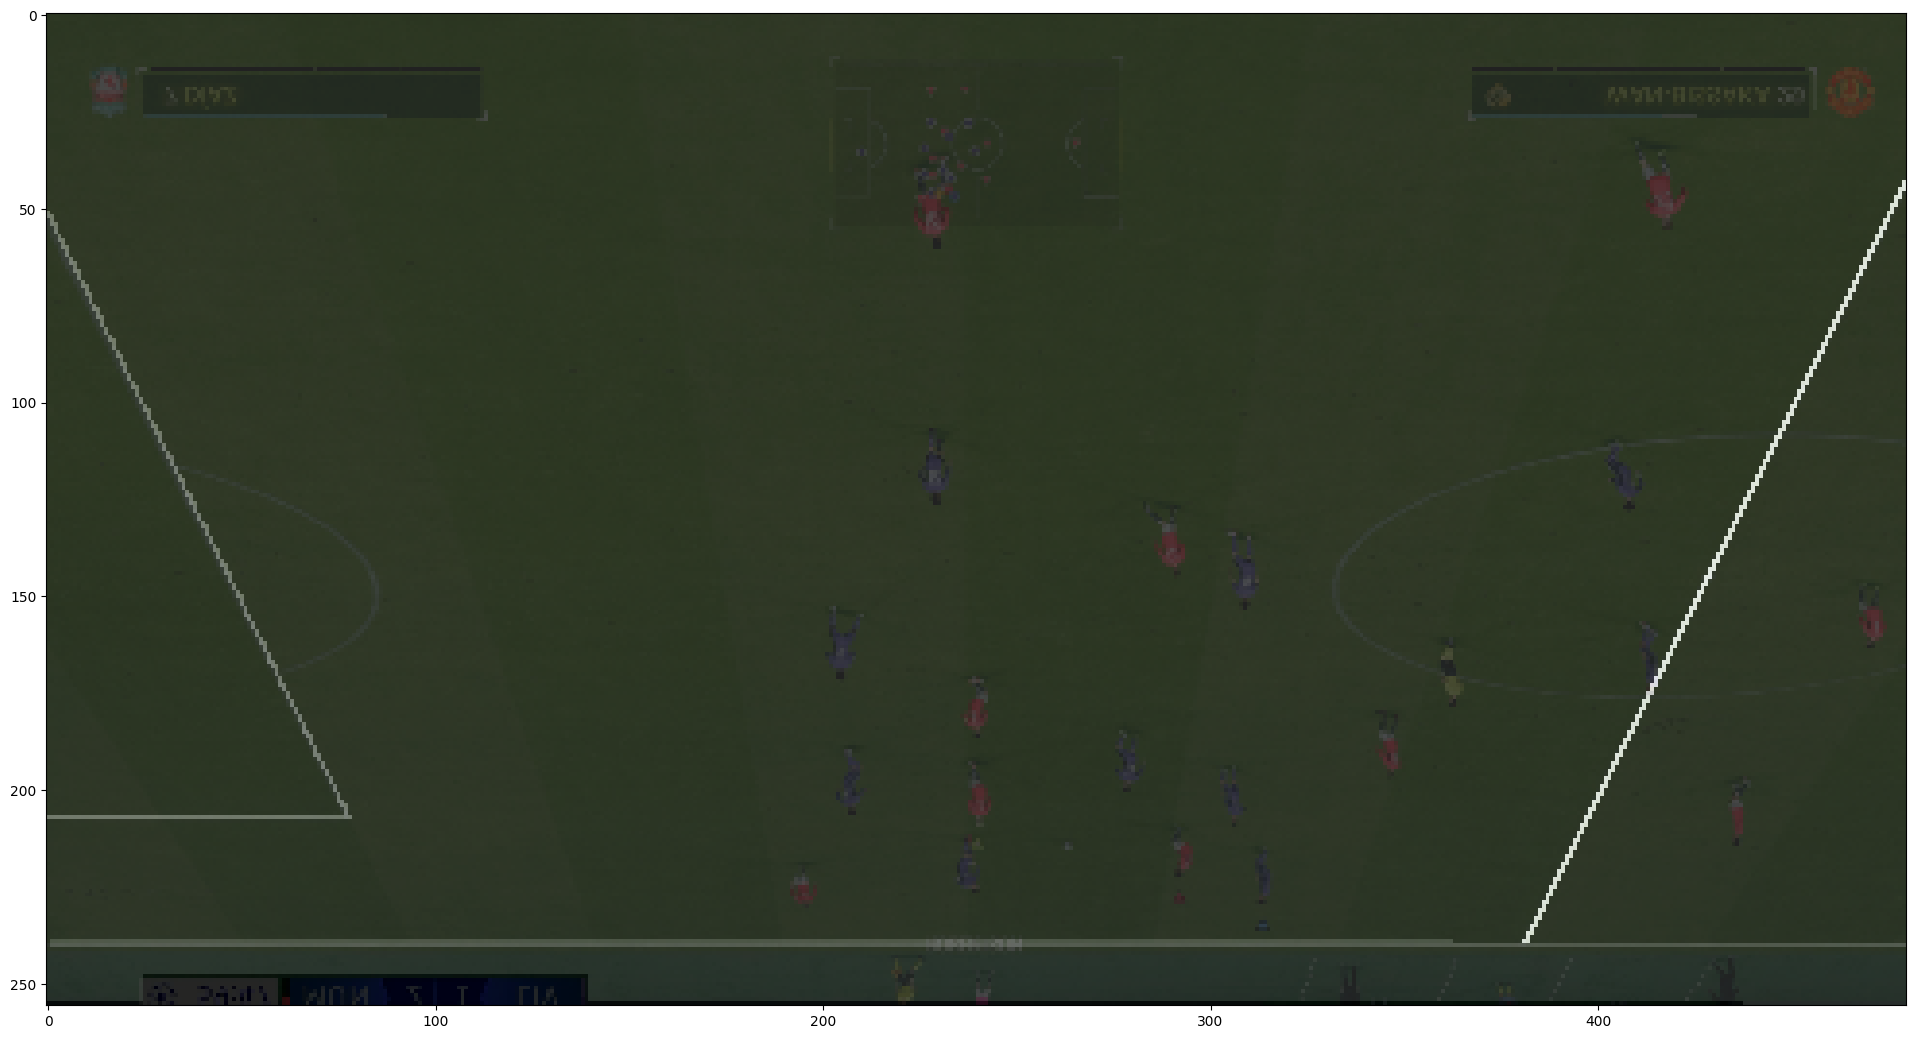

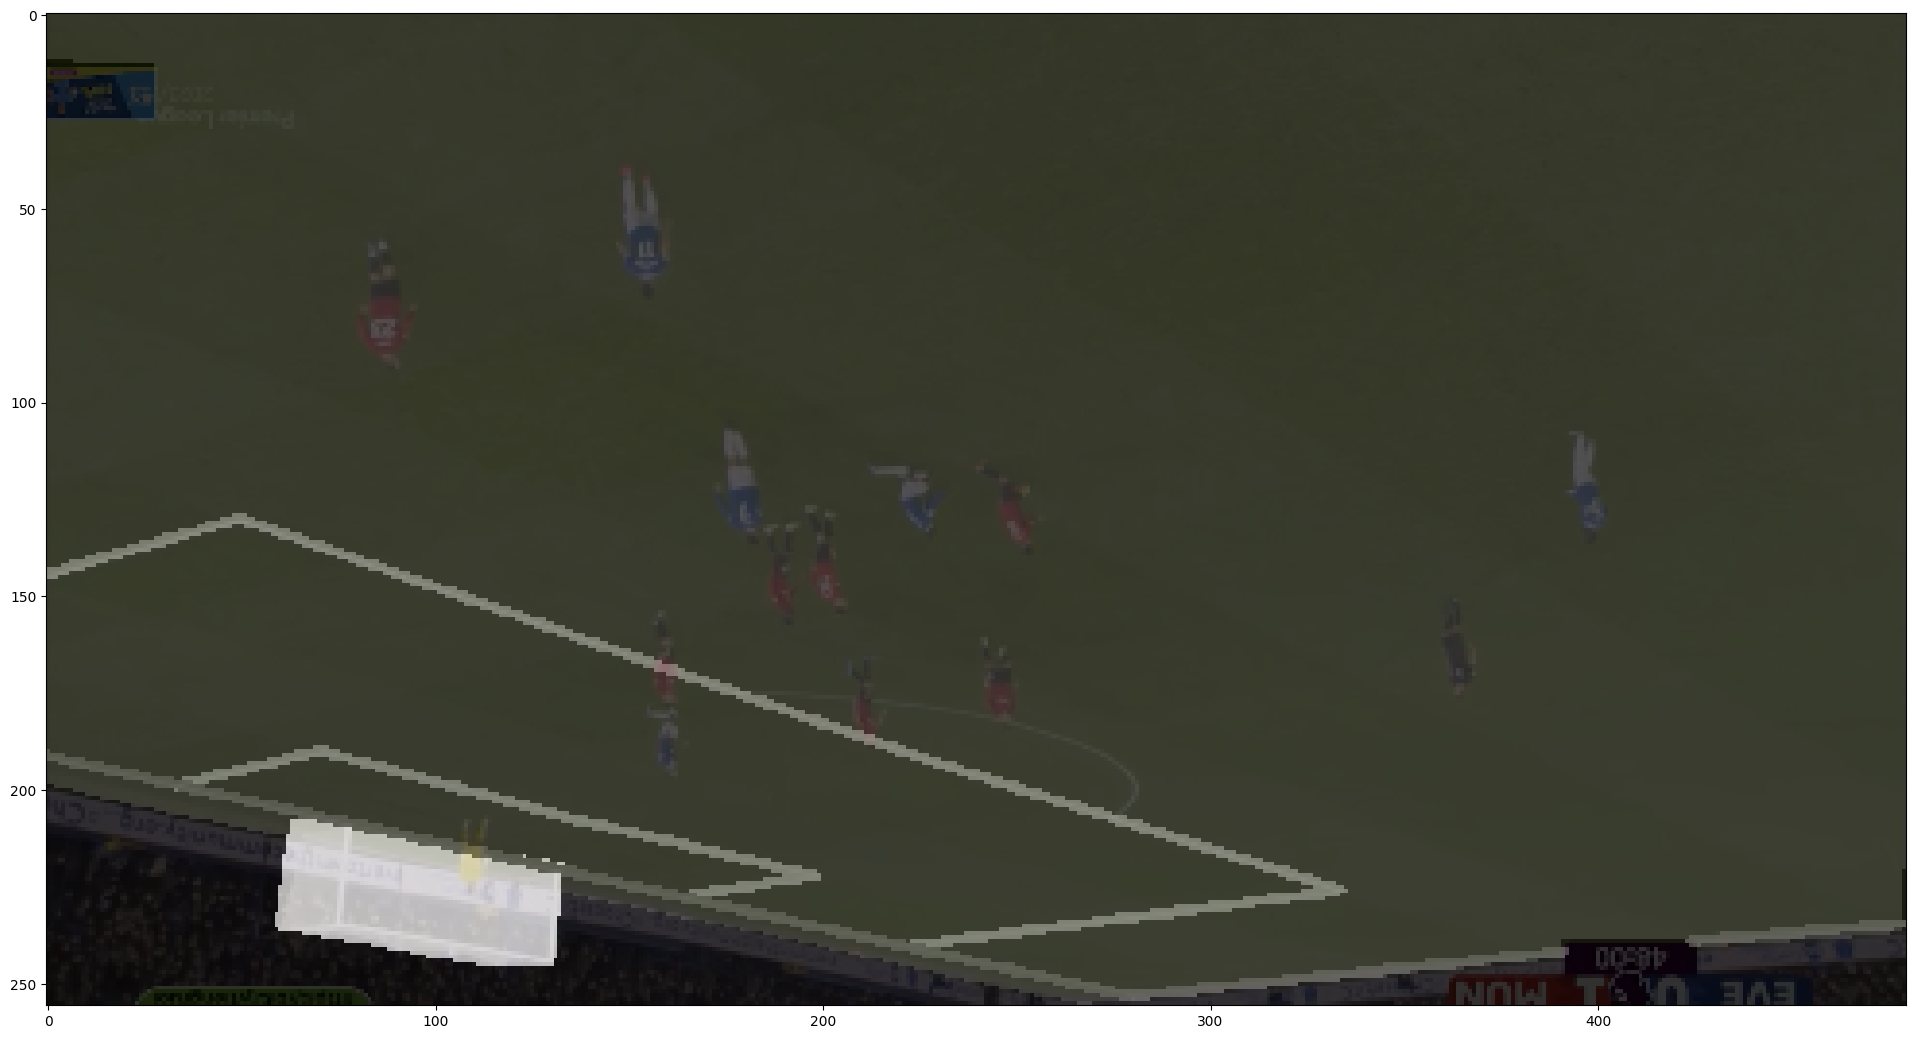

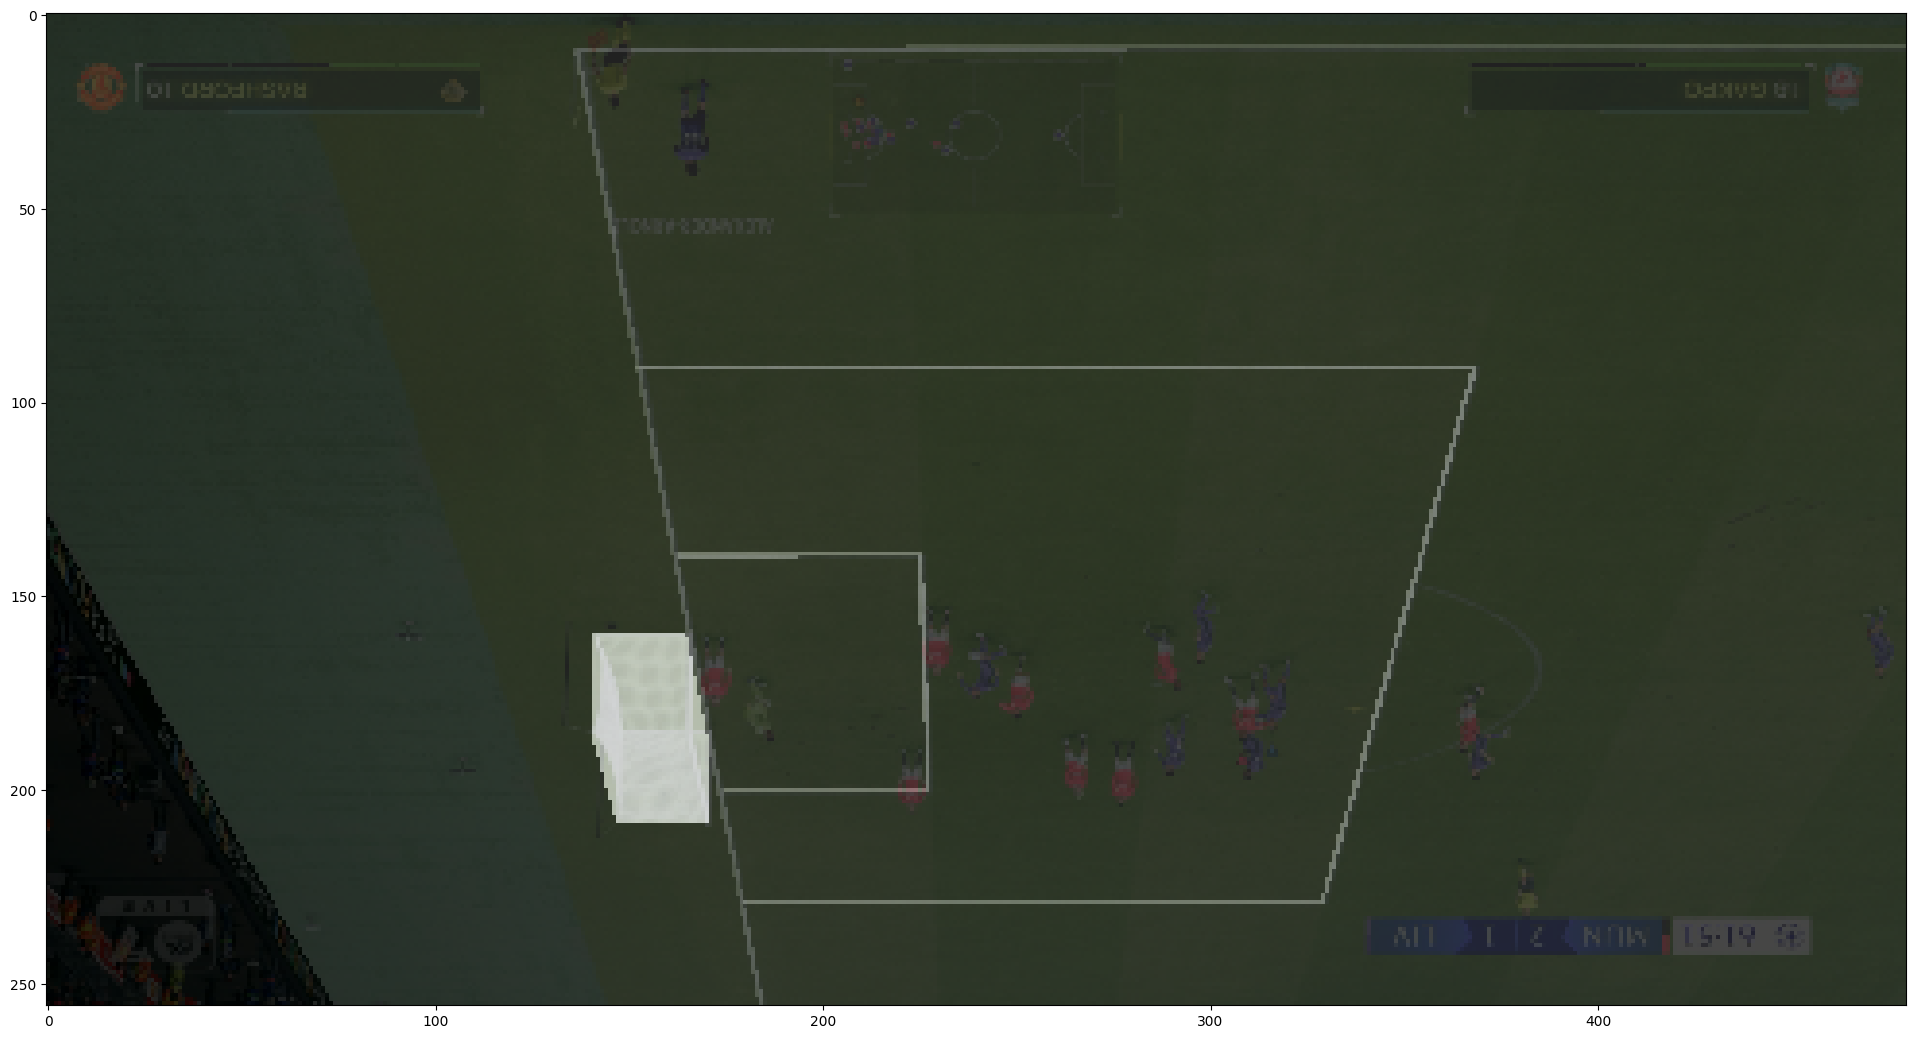

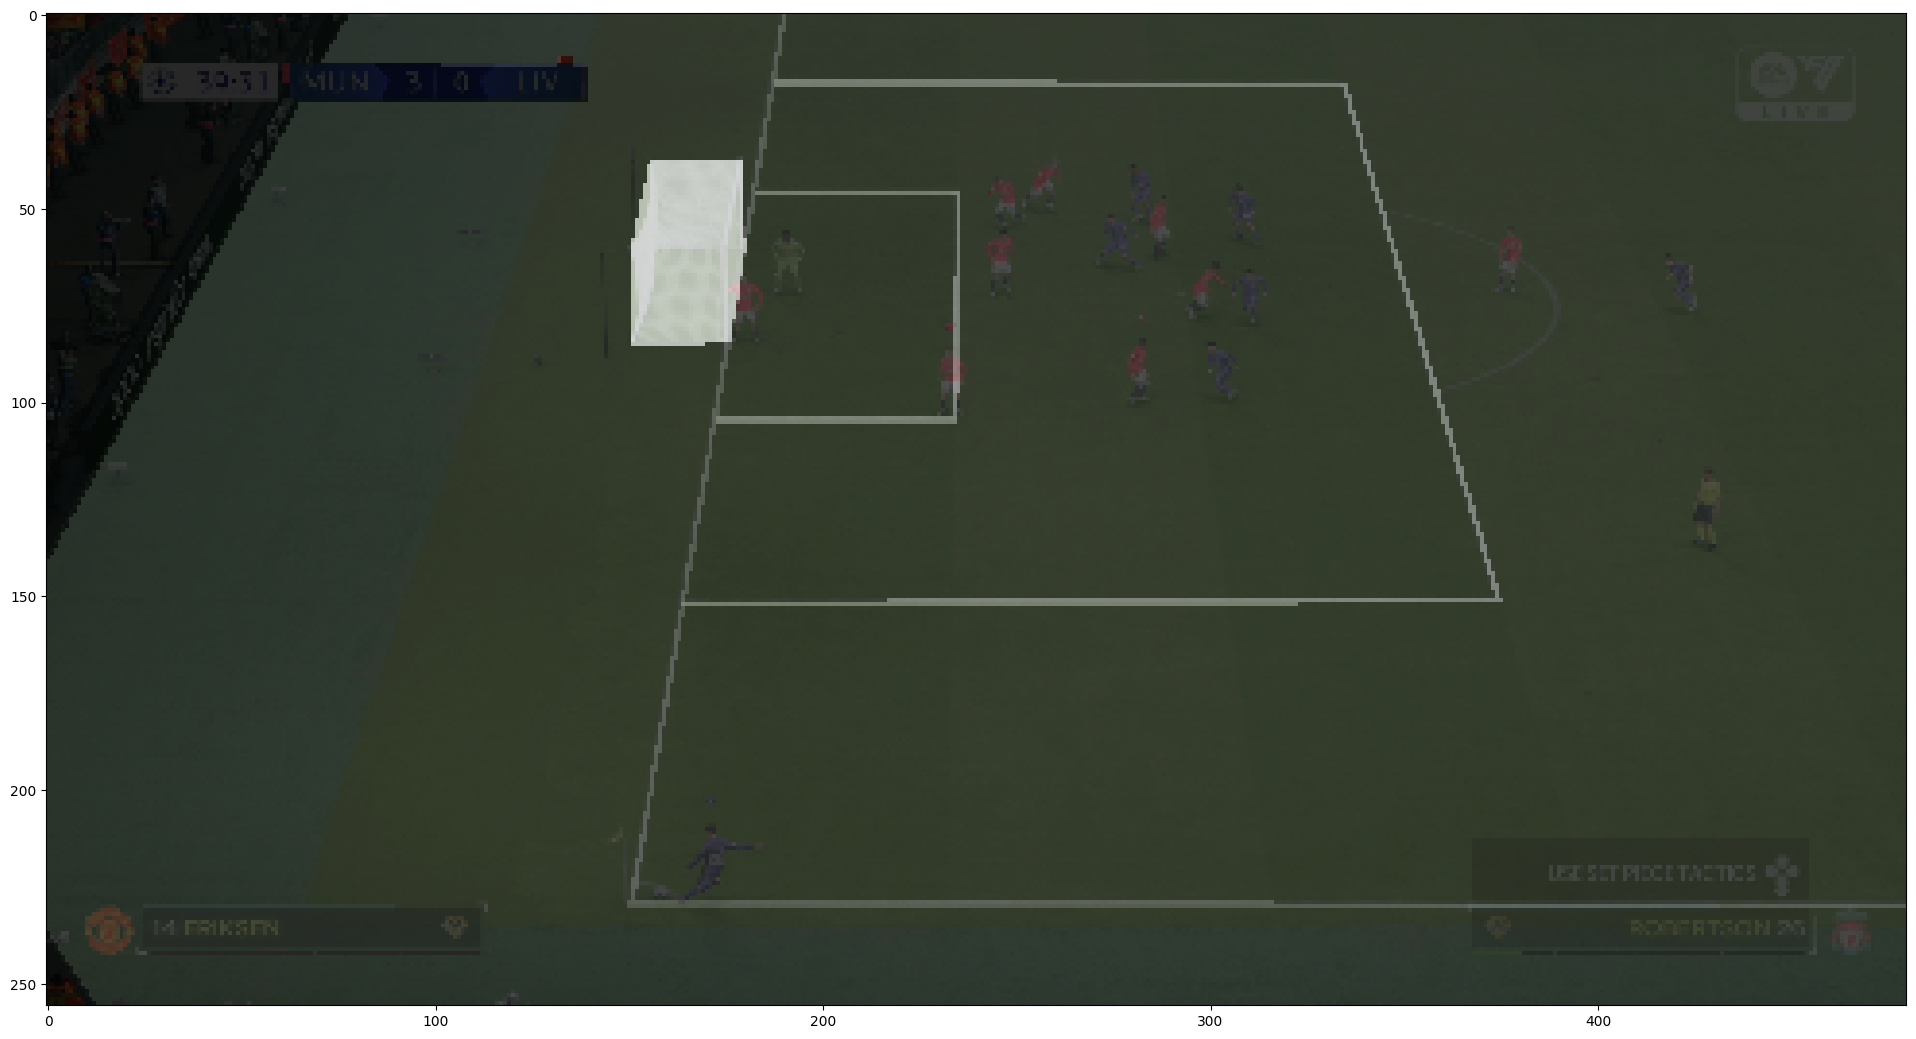

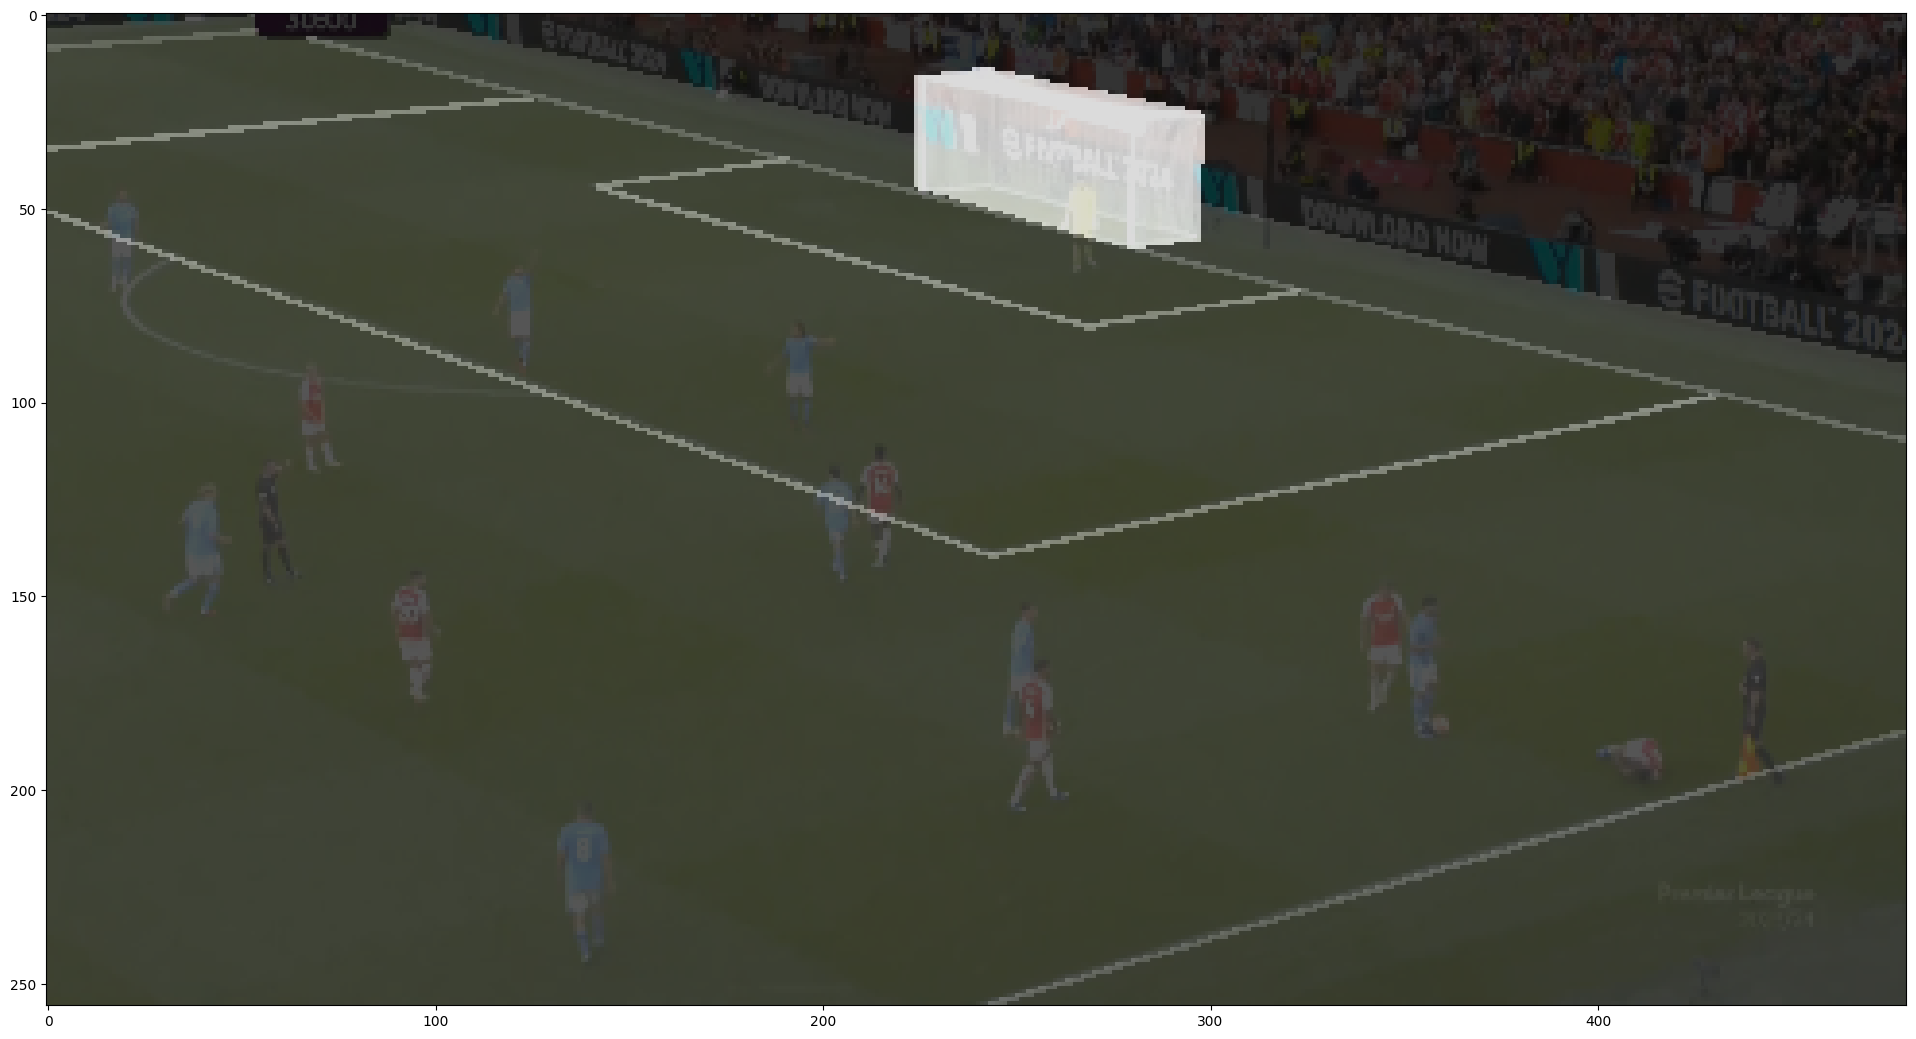

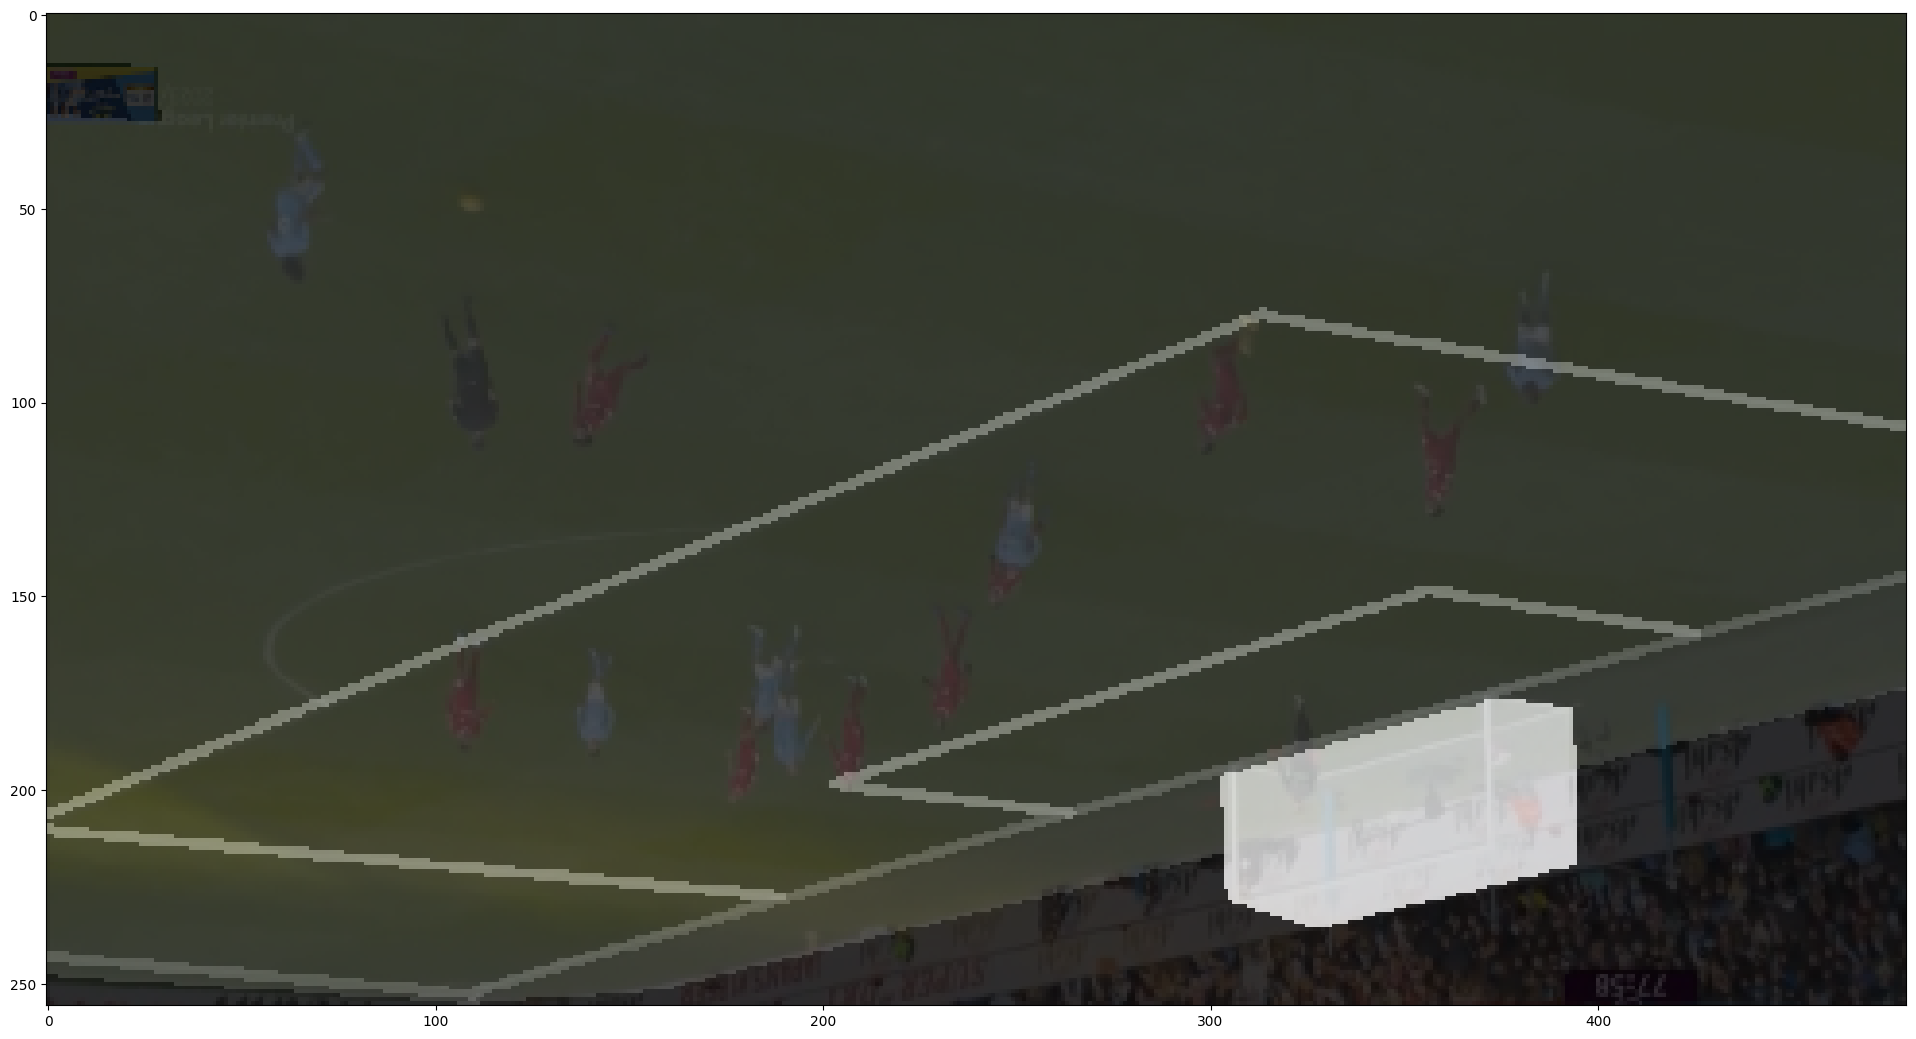

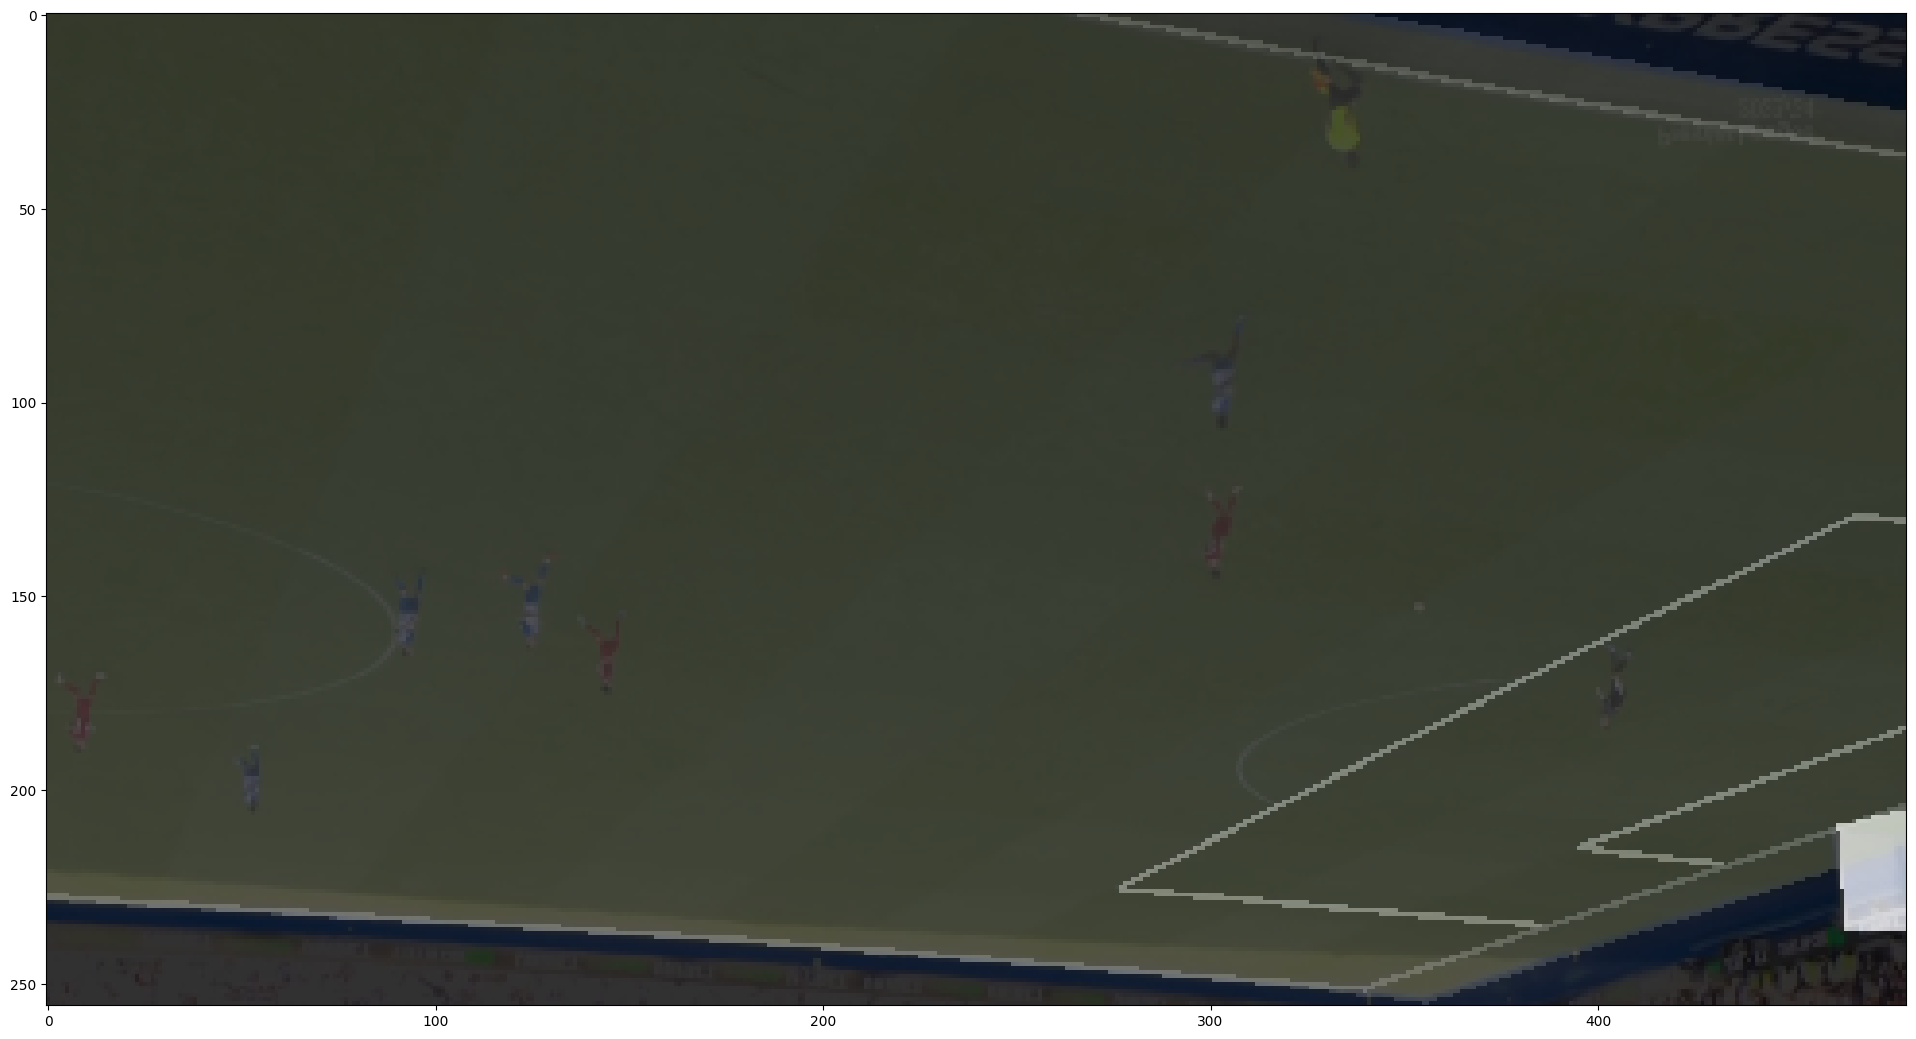

In [5]:
image_folder = os.path.join(complete_dataset_path, "images")
annotation_file = os.path.join(complete_dataset_path, "annotations", "instances_default.json")

transform = albumentations.Compose([
        albumentations.Resize(256, 480),
        albumentations.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        albumentations.HorizontalFlip(p=0.5),
        albumentations.VerticalFlip(p=0.5)
        ])

batch_size = 16
dataset = PitchObjectDataset(image_folder=image_folder, annotation_file=annotation_file
                       , transform=transform)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
images, masks, one_hot_mask = next(iter(data_loader))

for i in range(int(batch_size/2)):
    plt.figure()
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.imshow((masks[i].permute(1, 2, 0).numpy()*255).astype(np.int32), cmap='gray',
               vmin=0, vmax=255, alpha=0.8)


### Train model

torch.Size([16, 3, 256, 480]) torch.Size([16, 7, 256, 480])
Batch id: 0
tensor([0, 1, 2, 3, 5], dtype=torch.int32)
     Class id: 0 , Class iou: 0.0023129740729928017
     Class id: 1 , Class iou: 5.819805193318928e-10
     Class id: 2 , Class iou: 6.187871881557783e-10
     Class id: 3 , Class iou: 4.776044004728419e-10
     Class id: 5 , Class iou: 6.964952503629718e-10
Image IoU: 0.0005782441003248096
Batch id: 1
tensor([0, 1, 2, 3, 5], dtype=torch.int32)
     Class id: 0 , Class iou: 0.04742616415023804
     Class id: 1 , Class iou: 6.405102559448039e-10
     Class id: 2 , Class iou: 6.092490401066186e-10
     Class id: 3 , Class iou: 5.010551973327892e-10
     Class id: 5 , Class iou: 6.595415880106259e-10
Image IoU: 0.01185654103755951
Batch id: 2
tensor([0, 1, 2, 3, 5], dtype=torch.int32)
     Class id: 0 , Class iou: 0.018835414201021194
     Class id: 1 , Class iou: 5.846764183914388e-10
     Class id: 2 , Class iou: 6.427141041598361e-10
     Class id: 3 , Class iou: 4.761438

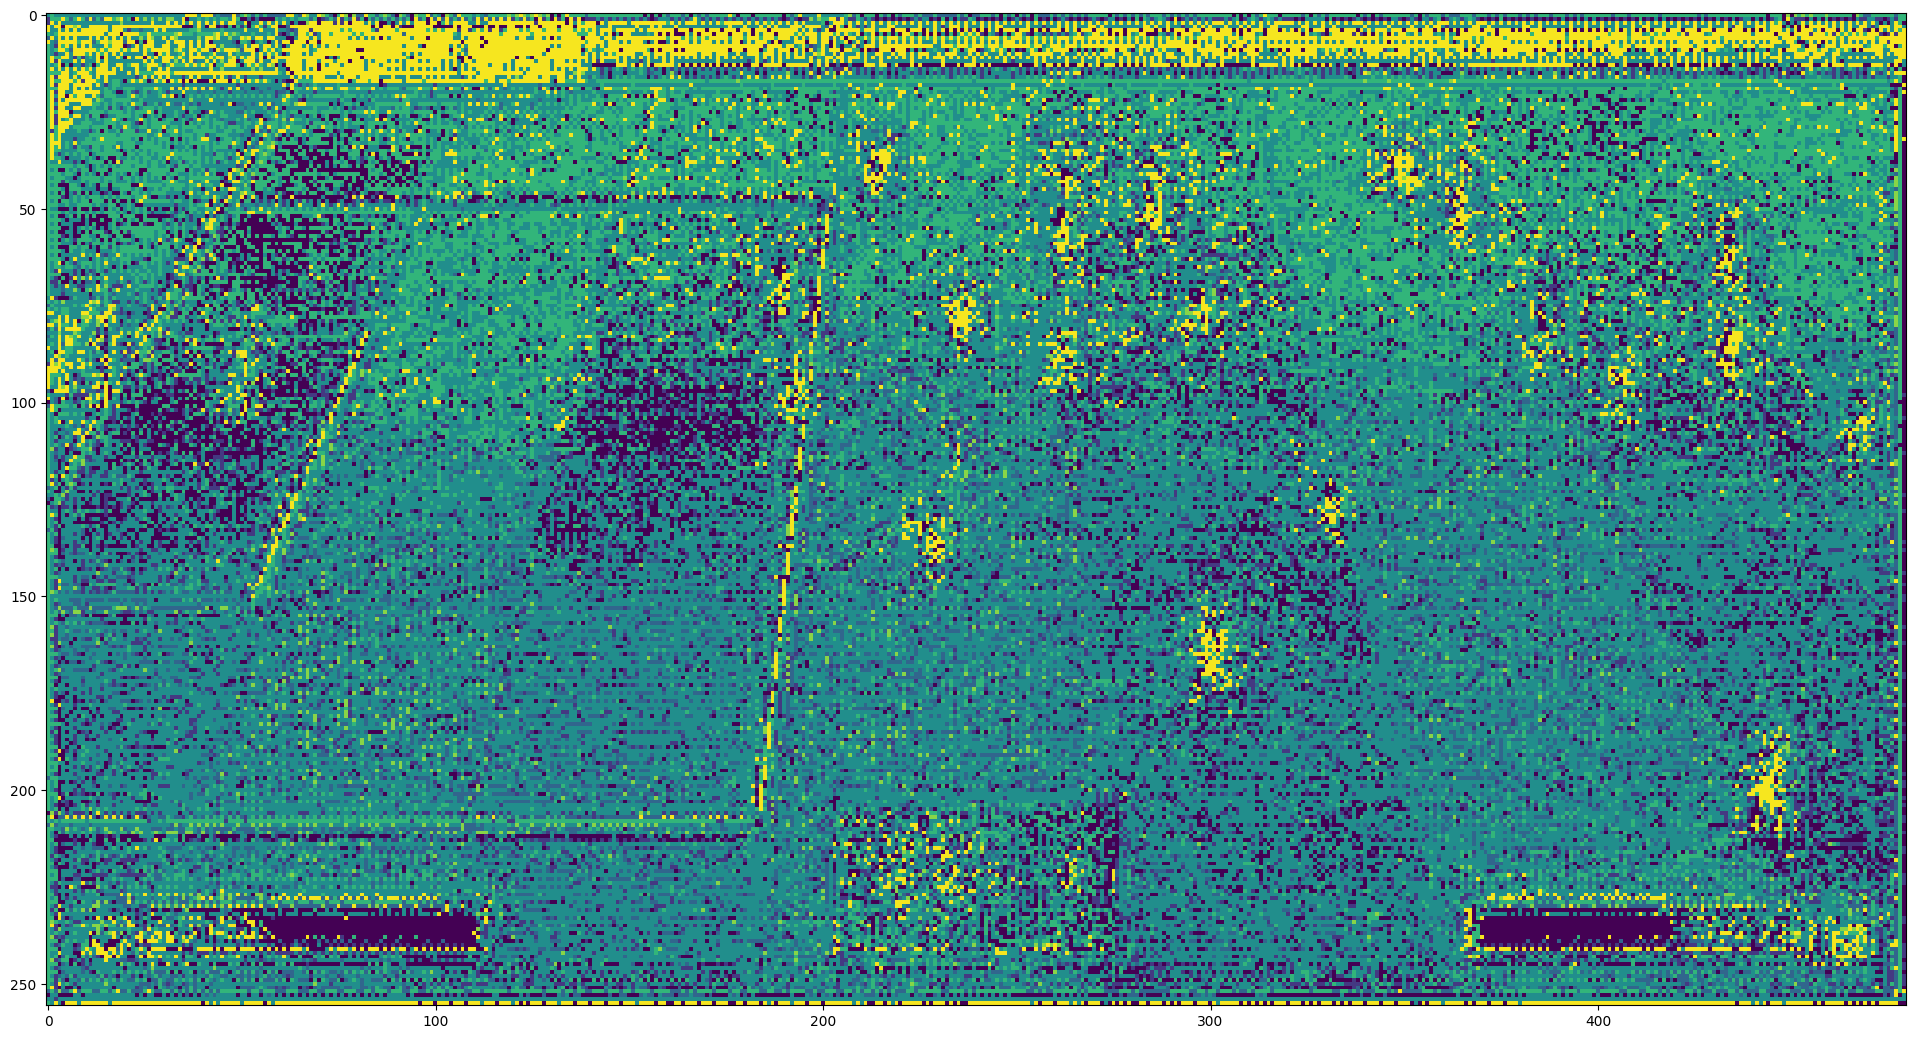

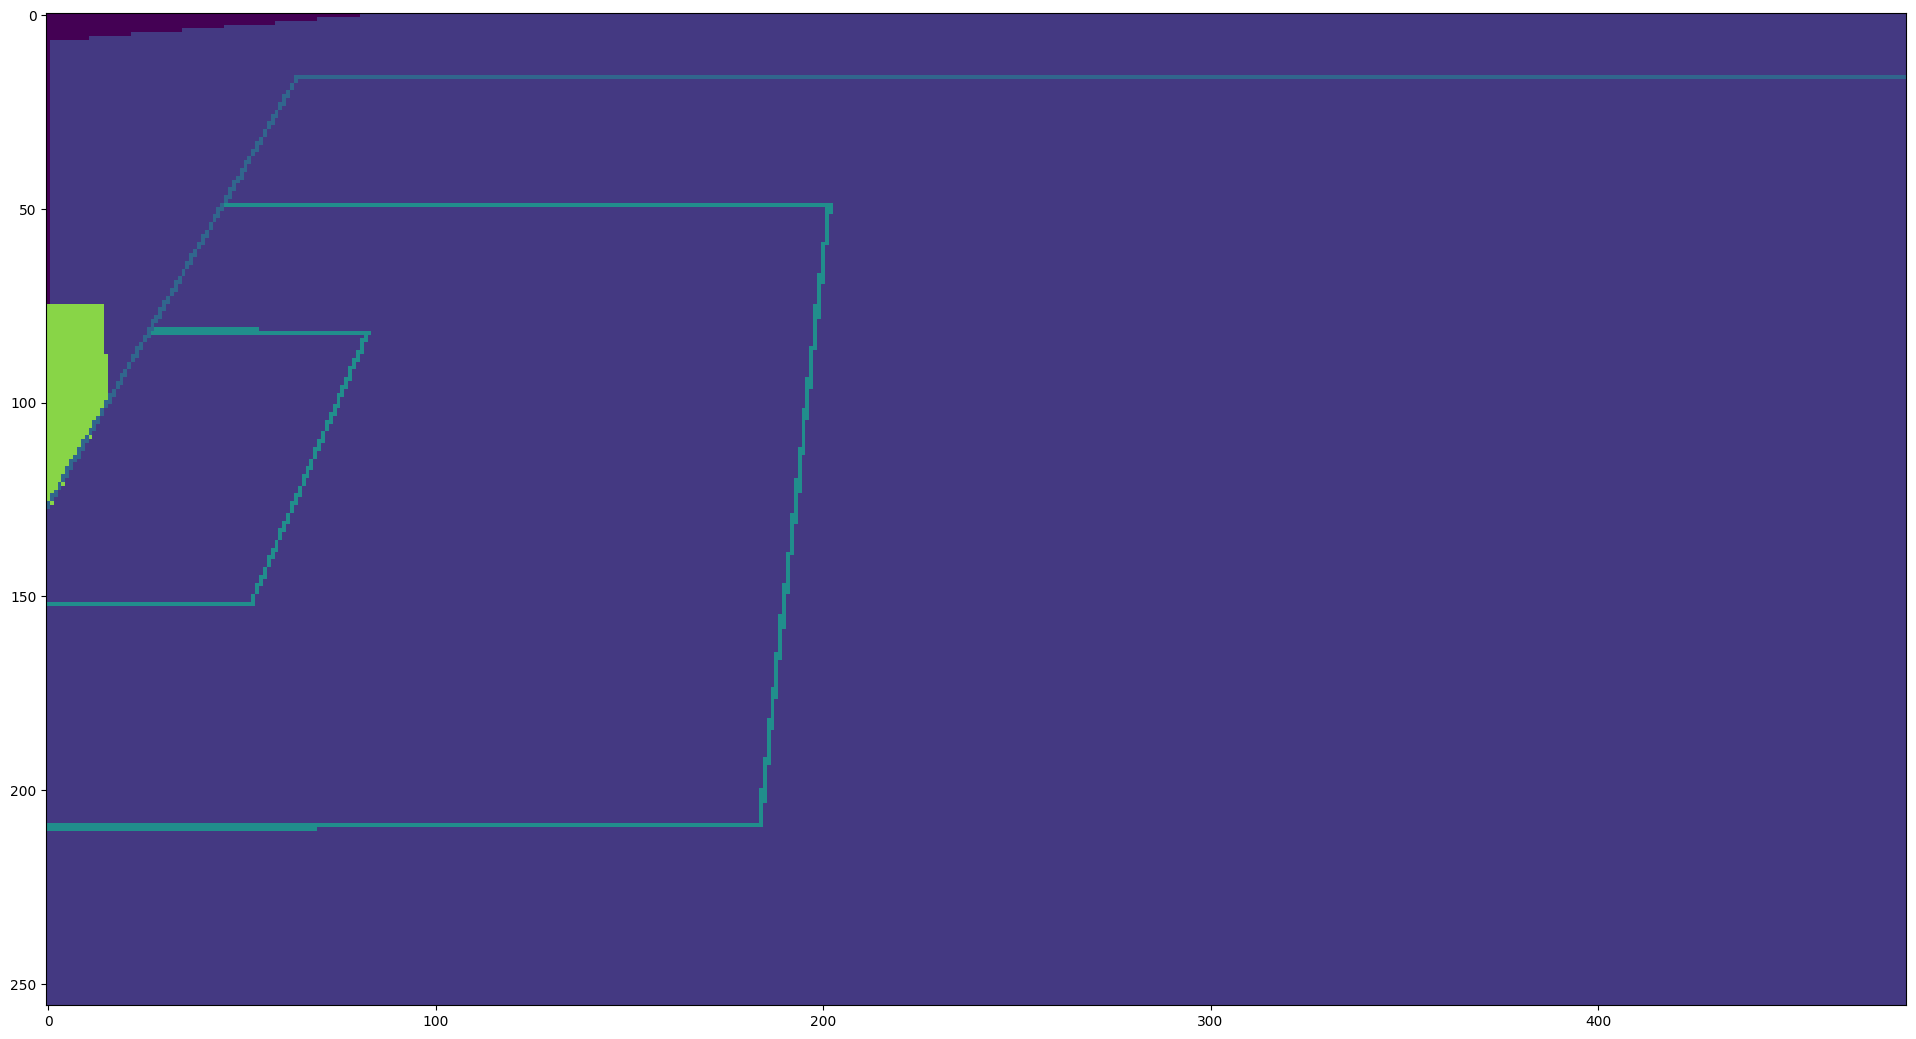

In [6]:
class encoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = conv_block(in_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))
        
    def forward(self, inputs):
        x = self.conv(inputs)
        #if self.pool(x).size()[3] % 2 != 0:
            #x = F.pad(x, (1, 1, 0, 0), "constant", 0)
        p = self.pool(x)

        return x, p
    
    
class decoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)
        self.conv = conv_block(out_c + out_c, out_c)
        
    def forward(self, inputs, skip):
        x = self.up(inputs)
        if skip.size()[3] == x.size()[3] + 1:
            x = F.pad(x, (1, 0, 0, 0), "constant", 0)
        x = torch.cat([x, skip], axis=1)
        x = self.conv(x)
        return x    
    

images, masks, _ = next(iter(data_loader))

e1 = encoder_block(3, 64)
e2 = encoder_block(64, 128)
e3 = encoder_block(128, 256)
e4 = encoder_block(256, 512)
b = conv_block(512, 1024)
dc4 = decoder_block(1024, 512)
dc3 = decoder_block(512, 256)
dc2 = decoder_block(256, 128)
dc1 = decoder_block(128, 64)
outputs = nn.Conv2d(64, 7, kernel_size=1, padding=0)
sigmoid = nn.Sigmoid()
softmax = nn.Softmax(dim=1)

s1, p1 = e1(images)
s2, p2 = e2(p1)
s3, p3 = e3(p2)
s4, p4 = e4(p3)
b = b(p4)
d1 = dc4(b, s4)
d2 = dc3(d1, s3)
d3 = dc2(d2, s2)
d4 = dc1(d3, s1)
outputs = outputs(d4)
print(images.size(), outputs.size())
# sigmoid(outputs)
pred = softmax(outputs)

preds = pred
targets = masks

preds = preds.view(-1, 7, preds.size(2), preds.size(3))
targets = targets.view(-1, 1, targets.size(2), targets.size(3))

iou_sum = 0.0
total_present_classes = 0
smooth=1e-5
for batch_idx in range(preds.size(0)):
    print("Batch id:",batch_idx)
    present_classes = (targets[batch_idx].unique() * 255/42).int() # Convert to long
    print(present_classes)

    iou_target = 0.0
    for class_id in present_classes:
        #if class_id == 0:  # Skip background class
            #continue
        
        # Convert targets to one-hot encoding for the current class
        class_mask = (targets[batch_idx] == class_id*255/42).float()

        # Calculate intersection and union for the current class
        intersection = torch.sum(preds[batch_idx, class_id, :, :] * class_mask)
        union = torch.sum(preds[batch_idx, class_id, :, :] + class_mask) - intersection

        # Calculate IoU for the current class and add to the sum
        class_iou = (intersection + smooth) / (union + smooth)  # Adding a small epsilon to avoid division by zero
        print("     Class id:",class_id.item(), ", Class iou:", class_iou.item())
        iou_target += class_iou
        total_present_classes += 1
    iou_target = iou_target / (present_classes.size(0) - 1)
    print("Image IoU:", iou_target.item())
    iou_sum += iou_target
# Average over present classes and compute the mean IoU score
iou = iou_sum / preds.size(0)
print("\nTotal IoU:", iou.item())

class_iou_sum = 0.0
total_present_classes = 0

for class_id in range(1, 6):  # Include background class 0
    class_iou_class_sum = 0.0
    present_images = 0

    print("Class id:",class_id)
    for batch_idx in range(preds.size(0)):
        # Check if the current class is present in the target image
        if (targets[batch_idx]*255/42 == class_id).any().item():
            present_images += 1

            # Convert targets to one-hot encoding for the current class
            class_mask = (targets[batch_idx]*255/42 == class_id).float()

            # Calculate intersection and union for the current class
            intersection = torch.sum(preds[batch_idx, class_id, :, :] * class_mask)
            union = torch.sum(preds[batch_idx, class_id, :, :] + class_mask) - intersection

            # Calculate IoU for the current class and add to the sum
            class_iou = (intersection + 1e-6) / (union + 1e-6)  # Adding a small epsilon to avoid division by zero
            class_iou_class_sum += class_iou

            print("    Batch id:",batch_idx, ", Class iou:", class_iou.item())

    if present_images > 0:
        # Average IoU for the current class across all images
        class_iou_avg = class_iou_class_sum / present_images
        print("Average class IoU:", class_iou_avg.item())
        class_iou_sum += class_iou_avg
        total_present_classes += 1

# Average over classes and compute the mean IoU score
iou = class_iou_sum / total_present_classes
print("\nTotal IoU:", iou.item())

pred = softmax(outputs)
pred = torch.argmax(pred, dim=1).squeeze(1)
label = (masks*255).squeeze(1)

print(pred.size(), label.size())

plt.figure()
plt.imshow((pred[0]*42).numpy().astype(np.int32),
               vmin=0, vmax=255)
print(np.unique(pred[0]*42))
plt.figure()
plt.imshow((label[0]).numpy().astype(np.int32),
               vmin=0, vmax=255)
print(np.unique(label[0]))

In [7]:
if train:
    temp = None
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PitchObjectSegmentation().to(device)
    print(device)

    criterion = iou_multiclass_loss
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-4)
    average_loss_list = []
    scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    epochs = 50
    model.train()
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets in tqdm(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            outputs_softmax = F.softmax(outputs, dim=1)
            outputs_argmax = torch.argmax(outputs_softmax, dim=1)
            print(outputs_argmax.size(), targets.size())
            loss = criterion(outputs, (targets.squeeze(1) * 255 / 42).long())
            if loss.item() < 0:
                print(loss.item())
                temp = inputs.cpu(), outputs.cpu(), targets.cpu()
                break
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(data_loader)
        average_loss_list.append(average_loss)
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {average_loss}')

    plt.figure()
    plt.plot(range(1, epochs+1), average_loss_list, label='loss')
    plt.yscale("log")
    plt.title("Training Loss")
    plt.legend()

    model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
    model_name = 'pitch_object_detect'
    torch.save(model.state_dict(), os.path.join(model_path, model_name))


In [8]:
model = smp.Unet("resnet34", encoder_weights="imagenet", activation=None, classes=7)
preds = model(images)
#plt.figure()
#plt.imshow((masks[0]*255).squeeze().numpy(), vmin=0, vmax=255)

targets_one_hot = torch.zeros_like(preds)
targets_one_hot.scatter_(1, (masks*255/42).long(), 1)
temp = targets_one_hot[0]
for i in range(temp.size()[0]):
    temp_nth_channel = (temp[i].squeeze()*255).numpy()
    #print(np.unique(temp_nth_channel))
    #plt.figure()
    #plt.imshow(temp_nth_channel, vmin=0, vmax=255)
for inputs, targets, _ in tqdm(data_loader):
    preds = model(inputs)
    targets_one_hot = torch.zeros_like(preds)
    targets_one_hot.scatter_(1, (targets*255/42).long(), 1)
    
    smooth = 1e5
    dice_sum = 0.
    for i in range(preds.size()[1]):
        channel_pred = preds[:, i, :, :]
        channel_target = targets_one_hot[:, i, :, :]
        channel_iflat = torch.sigmoid(channel_pred).flatten()
        channel_tflat =  channel_target.flatten()
        channel_intersection = (channel_iflat * channel_tflat).sum()
        dice_channel = 1 - ((2.0 * channel_intersection + smooth) / (channel_iflat.sum() + channel_tflat.sum() + smooth))

        if dice_channel > 1:
            print(dice_channel)
            plt.figure()
            plt.imshow(channel_target*255, vmin=0, vmax=255)
        dice_channel = dice_channel*0.2 if i==1 else dice_channel
        dice_sum += dice_channel
    dice_sum = dice_sum/preds.size()[1]

100%|██████████| 39/39 [01:26<00:00,  2.21s/it]


cuda


100%|██████████| 39/39 [00:26<00:00,  1.45it/s]


Epoch [1/50], Loss: 0.7496402477606748


100%|██████████| 39/39 [00:20<00:00,  1.87it/s]


Epoch [2/50], Loss: 0.7185967350617434


...

Epoch [48/50], Loss: 0.5037921300301185


100%|██████████| 39/39 [00:20<00:00,  1.86it/s]


Epoch [49/50], Loss: 0.4934870936931708


100%|██████████| 39/39 [00:20<00:00,  1.86it/s]


Epoch [50/50], Loss: 0.5062245504978375


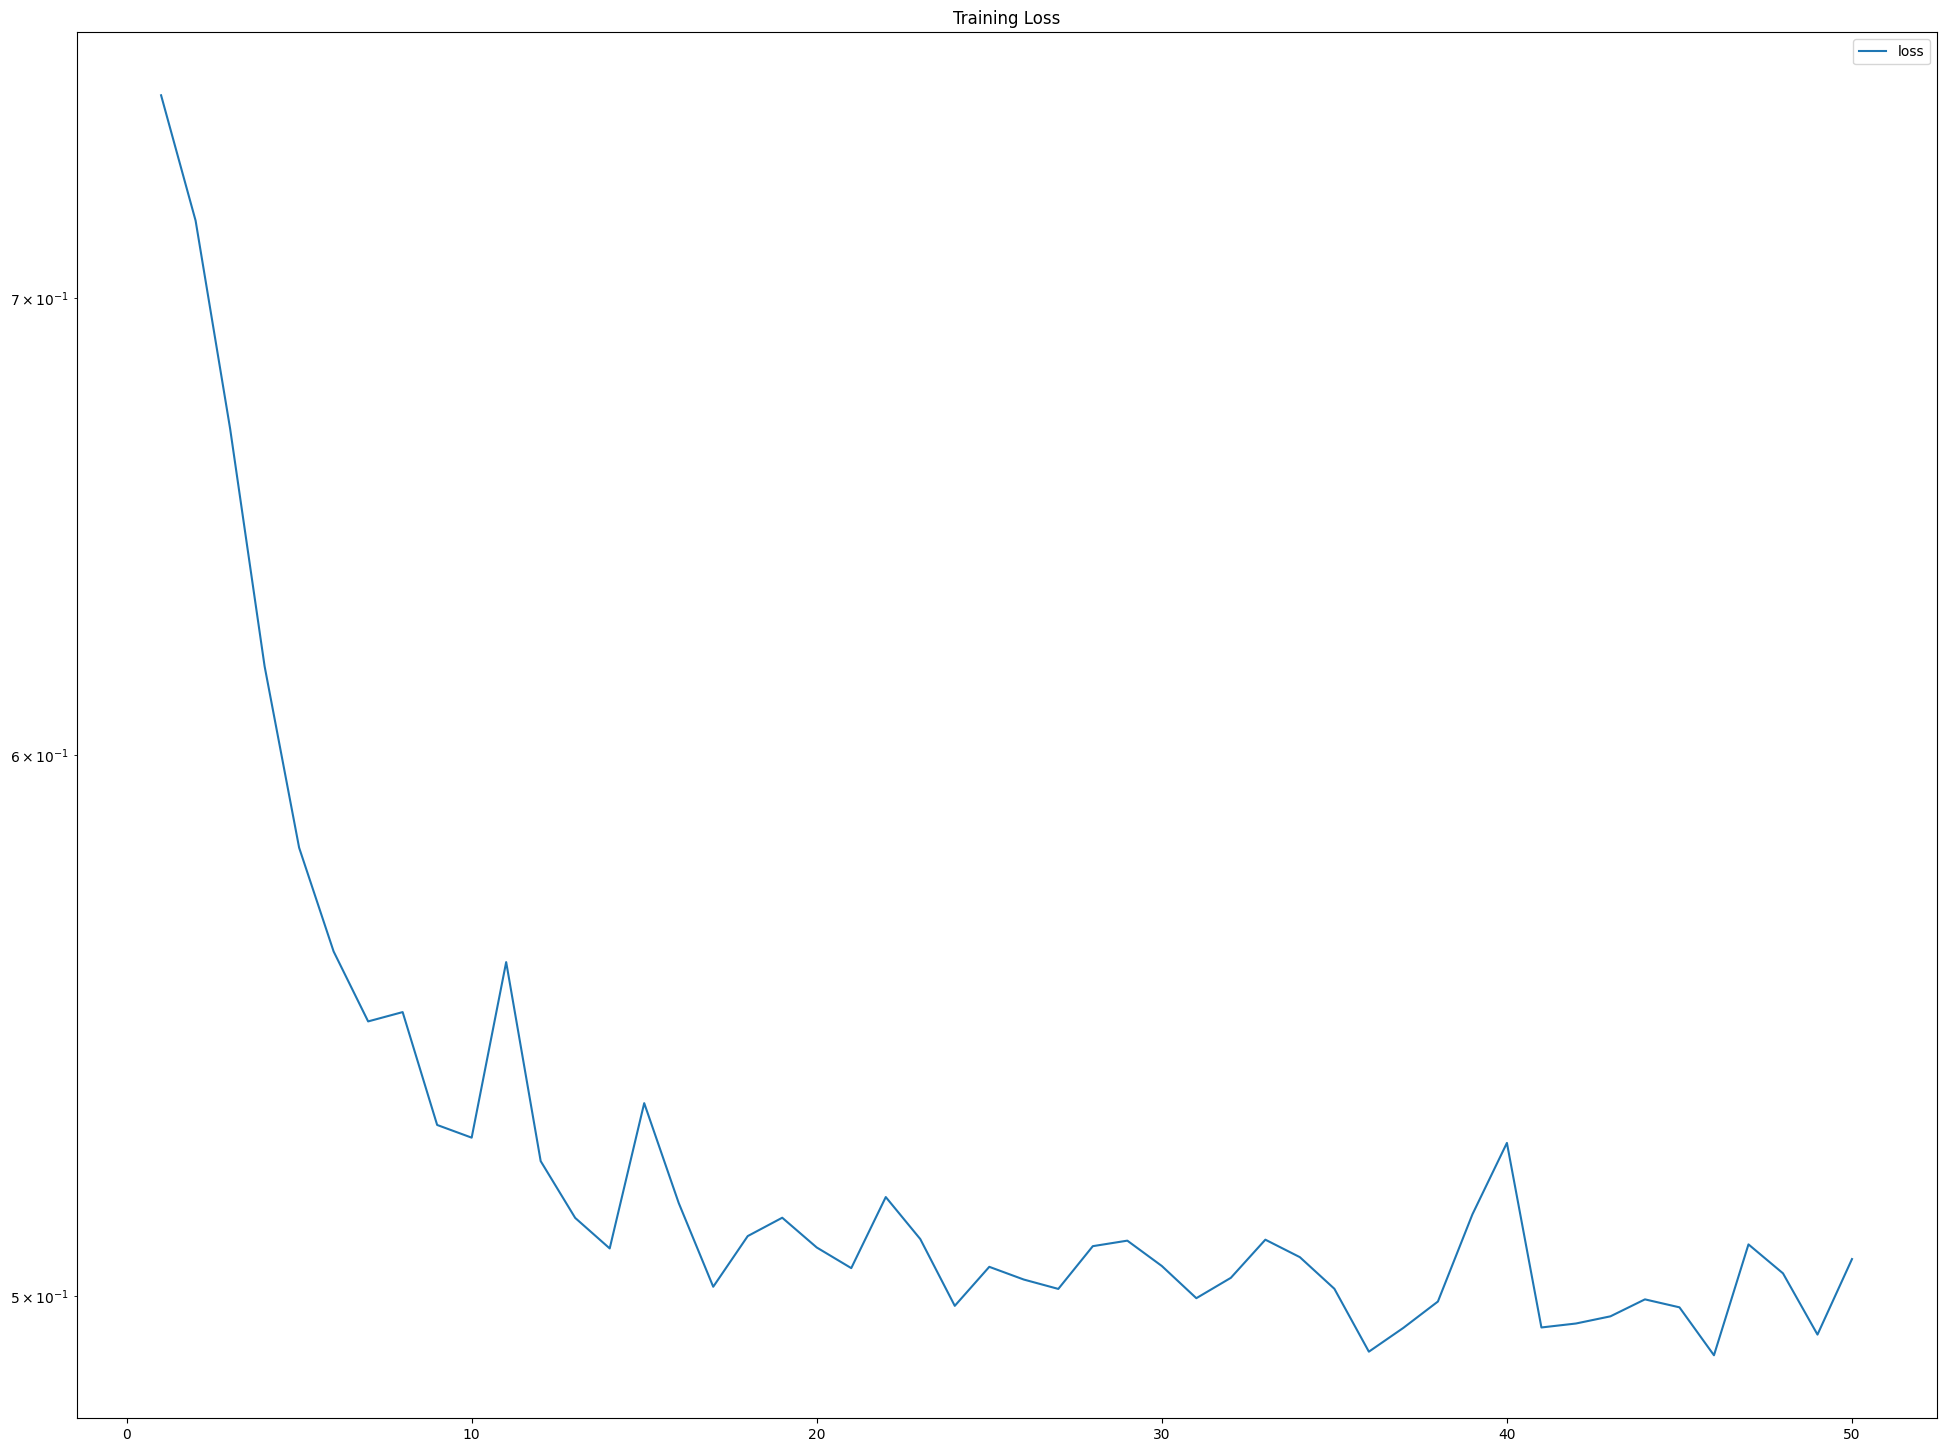

In [9]:
model = smp.Unet("resnet34", encoder_weights="imagenet", activation=None, classes=7)
model

if res_unet_train:
    temp = None
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(device)

    criterion = dice_loss
    optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-4)
    average_loss_list = []
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.2)

    epochs = 50
    model.train()
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets, _ in tqdm(data_loader):
            inputs, targets  = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            preds = model(inputs)
            
            targets_one_hot = torch.zeros_like(preds)
            targets_one_hot.scatter_(1, (targets*255/42).long(), 1)
            
            loss = criterion(preds, targets_one_hot)
            if loss.item() < 0:
                print(loss.item())
                temp = inputs.cpu(), preds.cpu(), targets.cpu()
                break
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(data_loader)
        average_loss_list.append(average_loss)
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {average_loss}')

    plt.figure()
    plt.plot(range(1, epochs+1), average_loss_list, label='loss')
    plt.yscale("log")
    plt.title("Training Loss")
    plt.legend()

    model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
    model_name = 'res_unet_pitch_object_detect'
    torch.save(model.state_dict(), os.path.join(model_path, model_name))

### Inference

In [11]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model_name = 'res_unet_pitch_object_detect'
model_path = os.path.join(model_path, model_name)
model = smp.Unet("resnet34", encoder_weights="imagenet", activation=None, classes=7)

vid_name = 'real_test'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

for image_name in sorted(os.listdir(images_path))[::10]:
    image_path = os.path.join(images_path, image_name)#sorted(os.listdir(images_path))[8])
    rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)  
    mask = pitch_detect_object_by_dl_model(rgb_image, model, model_path, visualize=True, device=device)
    print(np.unique(mask))
    if not os.path.exists(os.path.join(data_path, 'images/segment_object_by_dl')):
        os.mkdir(os.path.join(data_path, 'images/segment_object_by_dl'))                       
    cv2.imwrite(os.path.join(data_path, 'images/segment_object_by_dl/'+image_name[:-4] + '_mask.png'), mask)


TypeError: pitch_detect_object_by_dl_model() got multiple values for argument 'visualize'